# 🖼️ Deep Learning for Image Denoising — Convolutional Denoising Autoencoder on MNIST

---

> **Project Goal:** Build a state-of-the-art **Convolutional Denoising Autoencoder (CDAE)** that learns to reconstruct clean MNIST handwritten digit images from their noisy versions.

---

## 📋 Table of Contents

1. [Introduction & Theory](#1-introduction--theory)
2. [Environment Setup & Imports](#2-environment-setup--imports)
3. [Dataset Loading & Exploration](#3-dataset-loading--exploration)
4. [Noise Injection — Corrupting Images](#4-noise-injection--corrupting-images)
5. [Model Architecture](#5-model-architecture)
6. [Training Configuration](#6-training-configuration)
7. [Training Loop with Early Stopping](#7-training-loop-with-early-stopping)
8. [Loss Curves & Training Diagnostics](#8-loss-curves--training-diagnostics)
9. [Qualitative Evaluation — Visual Results](#9-qualitative-evaluation--visual-results)
10. [Quantitative Evaluation — PSNR & SSIM](#10-quantitative-evaluation--psnr--ssim)
11. [Latent Space Visualization (t-SNE)](#11-latent-space-visualization-t-sne)
12. [Noise Robustness Study](#12-noise-robustness-study)
13. [Model Summary & Conclusion](#13-model-summary--conclusion)

---


## 1. Introduction & Theory

### What is an Autoencoder?

An **Autoencoder** is an unsupervised neural network architecture that learns to:
1. **Encode** — Compress input data into a low-dimensional *latent space* (bottleneck)
2. **Decode** — Reconstruct the original input from the compressed representation

```
Input Image  →  [Encoder]  →  Latent Code  →  [Decoder]  →  Reconstructed Image
  (28×28)       (feature        (7×7×8)        (feature        (28×28)
                 maps)                          maps)
```

### Why a *Denoising* Autoencoder?

A **Denoising Autoencoder (DAE)** is trained with a specific objective:

> *Given a noisy (corrupted) version of an image, reconstruct the **clean** original.*

This forces the network to learn **robust, meaningful representations** of the underlying data distribution — not just a simple identity mapping. During training:

- **Input:** Noisy image `x̃ = x + noise`
- **Target:** Clean image `x`
- **Loss:** `MSE(decoder(encoder(x̃)), x)`

### Why Convolutional Layers?

Fully-connected autoencoders flatten images and lose **spatial structure**. Convolutional layers preserve spatial relationships, share weights, and are translation-invariant — making them vastly superior for image tasks.

### Architecture Design Decisions

| Component | Choice | Reason |
|-----------|--------|--------|
| Encoder | Conv2d + BatchNorm + ReLU + MaxPool | Hierarchical feature extraction |
| Bottleneck | 7×7×8 = 392 dims | Compact yet expressive |
| Decoder | Conv2d + BatchNorm + ReLU + Upsample | Stable training, no checkerboard artifacts |
| Output activation | Sigmoid | Pixel values ∈ [0, 1] |
| Loss | MSE (Pixel-wise) | Suitable for regression on pixel intensities |
| Optimizer | Adam with weight decay | Adaptive LR + regularization |
| Scheduler | ReduceLROnPlateau | Automatic LR annealing |

---


## 2. Environment Setup & Imports

We begin by importing all required libraries and setting reproducibility seeds for consistent results.


In [2]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from   matplotlib.colors import Normalize

import torch
import torch.nn as nn
import torch.nn.functional as F
from   torch.utils.data import DataLoader, SubsetRandomSampler

import torchvision
from   torchvision import datasets, transforms

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ── Device Configuration ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*60}")
print(f"  PyTorch Version : {torch.__version__}")
print(f"  Device Selected : {device}")
if device.type == 'cuda':
    print(f"  GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version    : {torch.version.cuda}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  GPU Memory      : {mem:.1f} GB")
print(f"{'='*60}")


  PyTorch Version : 2.10.0+cu128
  Device Selected : cuda
  GPU Name        : Tesla T4
  CUDA Version    : 12.8
  GPU Memory      : 15.6 GB


## 3. Dataset Loading & Exploration

### MNIST Dataset

The **MNIST** (Modified National Institute of Standards and Technology) dataset contains:
- **60,000** training images and **10,000** test images
- Grayscale handwritten digit images: 28×28 pixels
- 10 classes: digits 0–9

We split the training set into **80% train / 20% validation** for unbiased model selection.


In [3]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
BATCH_SIZE   = 128       # Larger batches → faster training, better gradient estimates
VALID_SPLIT  = 0.15      # 15% of training data used for validation
NUM_WORKERS  = 0         # Set >0 for faster data loading on multi-core machines

# ── Transform Pipeline ────────────────────────────────────────────────────────
# Only ToTensor here — we apply noise manually inside the training loop
transform = transforms.Compose([
    transforms.ToTensor(),          # [H,W] uint8  →  [1,28,28] float32 in [0,1]
])

# ── Download & Load Datasets ──────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ── Train / Validation Split (stratified-like using random shuffle) ───────────
n_train   = len(train_dataset)
indices   = list(range(n_train))
np.random.shuffle(indices)

split     = int(np.floor(VALID_SPLIT * n_train))
val_idx, train_idx = indices[:split], indices[split:]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler   = SubsetRandomSampler(val_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=val_sampler,   num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Training   samples : {len(train_idx):,}")
print(f"Validation samples : {len(val_idx):,}")
print(f"Test       samples : {len(test_dataset):,}")
print(f"Train batches      : {len(train_loader)}")
print(f"Val   batches      : {len(val_loader)}")
print(f"Test  batches      : {len(test_loader)}")


100%|██████████| 9.91M/9.91M [00:00<00:00, 69.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 28.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 62.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.12MB/s]


Training   samples : 51,000
Validation samples : 9,000
Test       samples : 10,000
Train batches      : 399
Val   batches      : 71
Test  batches      : 79


### 3.1 Visualising Raw (Clean) Samples

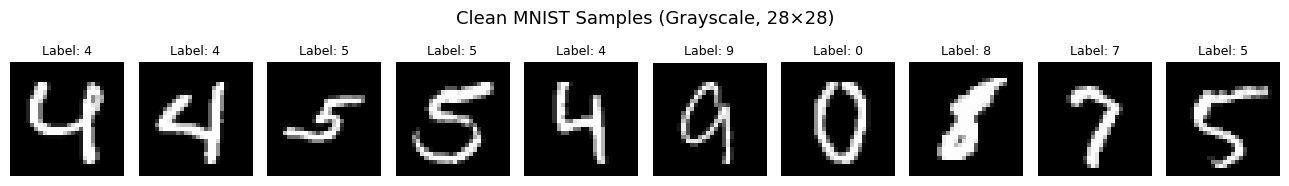


Dataset Pixel Statistics
  Min   : 0.0000
  Max   : 1.0000
  Mean  : 0.1307
  Std   : 0.3082
  Shape : torch.Size([51000, 1, 28, 28])  [N, C, H, W]


In [4]:
def show_clean_samples(loader, n_cols=10):
    """Display one row of clean MNIST images with their labels."""
    images, labels = next(iter(loader))
    images = images[:n_cols]
    labels = labels[:n_cols]

    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 1.3, 1.8))
    fig.suptitle('Clean MNIST Samples (Grayscale, 28×28)', fontsize=13, y=1.02)
    for i, (ax, img, lbl) in enumerate(zip(axes, images, labels)):
        ax.imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'Label: {lbl.item()}', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_clean_samples(train_loader)

# Dataset statistics
all_pixels = torch.cat([img for img, _ in train_loader], dim=0)
print(f"\nDataset Pixel Statistics")
print(f"  Min   : {all_pixels.min().item():.4f}")
print(f"  Max   : {all_pixels.max().item():.4f}")
print(f"  Mean  : {all_pixels.mean().item():.4f}")
print(f"  Std   : {all_pixels.std().item():.4f}")
print(f"  Shape : {all_pixels.shape}  [N, C, H, W]")


## 4. Noise Injection — Corrupting Images

We experiment with two types of noise commonly used for denoising tasks:

### Gaussian Noise
Adds continuous random values drawn from a Normal distribution.  
`x̃ = x + N(0, σ²)`  — σ controls the severity of corruption.

### Salt-and-Pepper Noise
Randomly sets pixels to 0 (pepper) or 1 (salt), simulating sensor errors.

We train on **Gaussian noise** (noise factor = 0.4) as it is the most general and challenging.


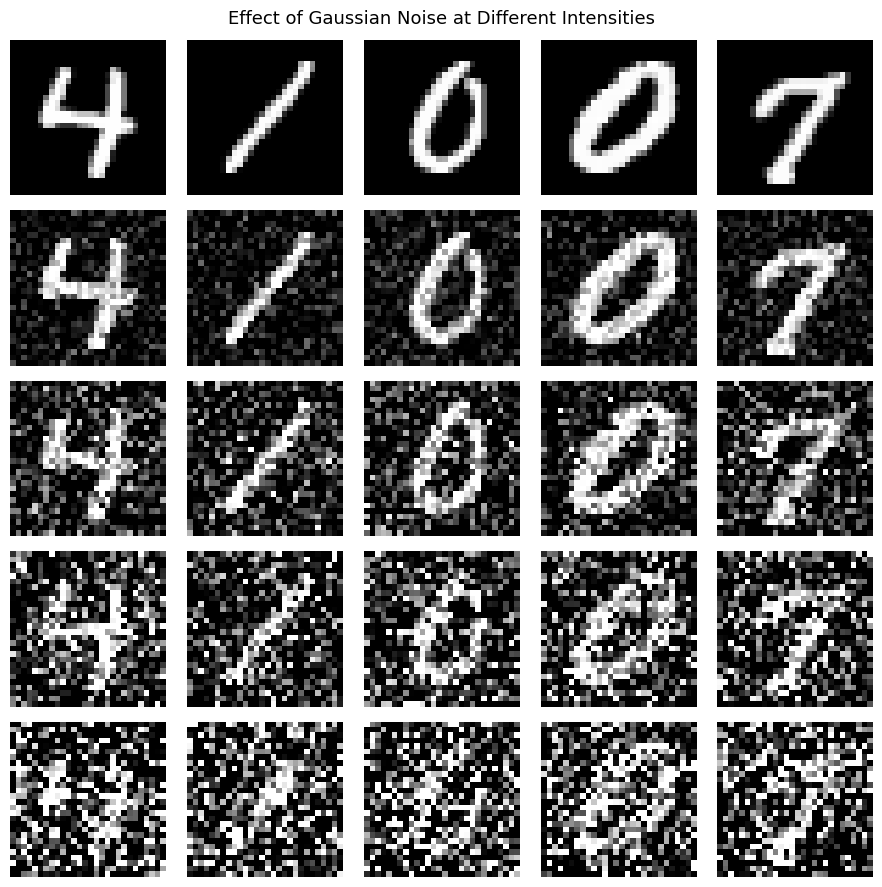

In [5]:
def add_gaussian_noise(images: torch.Tensor, noise_factor: float = 0.4) -> torch.Tensor:
    """
    Corrupt images with Additive White Gaussian Noise (AWGN).
    
    Args:
        images      : Clean images tensor  [B, C, H, W], values in [0, 1]
        noise_factor: Standard deviation of Gaussian noise (higher → more noise)
    
    Returns:
        Noisy images clamped to [0, 1]
    """
    noise  = torch.randn_like(images) * noise_factor
    noisy  = images + noise
    return noisy.clamp(0., 1.)


def add_salt_pepper_noise(images: torch.Tensor, amount: float = 0.05) -> torch.Tensor:
    """
    Corrupt images with Salt-and-Pepper (impulse) noise.
    
    Args:
        images : Clean images tensor  [B, C, H, W], values in [0, 1]
        amount : Proportion of pixels to corrupt (salt + pepper equally split)
    
    Returns:
        Noisy images in [0, 1]
    """
    noisy = images.clone()
    n_salt   = int(amount / 2 * images.numel())
    n_pepper = int(amount / 2 * images.numel())
    
    # Salt (white pixels)
    coords = [torch.randint(0, s, (n_salt,)) for s in images.shape]
    noisy[coords[0], coords[1], coords[2], coords[3]] = 1.0
    
    # Pepper (black pixels)
    coords = [torch.randint(0, s, (n_pepper,)) for s in images.shape]
    noisy[coords[0], coords[1], coords[2], coords[3]] = 0.0
    
    return noisy


# ── Visualise Both Noise Types ────────────────────────────────────────────────
def visualise_noise(loader, noise_factors=[0.0, 0.2, 0.4, 0.6, 0.8], n_images=5):
    images, labels = next(iter(loader))
    images = images[:n_images]
    
    n_rows = len(noise_factors)
    fig, axes = plt.subplots(n_rows, n_images, figsize=(n_images * 1.8, n_rows * 1.8))
    
    for r, nf in enumerate(noise_factors):
        noisy = add_gaussian_noise(images, nf)
        for c in range(n_images):
            ax = axes[r, c]
            ax.imshow(noisy[c].squeeze(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if c == 0:
                ax.set_ylabel(f'σ = {nf}', fontsize=10, rotation=90, labelpad=5)
    
    fig.suptitle('Effect of Gaussian Noise at Different Intensities', fontsize=13)
    plt.tight_layout()
    plt.show()

NOISE_FACTOR = 0.4  # ← Training noise level
visualise_noise(train_loader)


## 5. Model Architecture

### Convolutional Denoising Autoencoder (CDAE)

We design a deep convolutional architecture inspired by U-Net principles, featuring:

**Encoder:**
- 3 convolutional blocks (Conv → BatchNorm → ReLU → MaxPool)
- Progressive channel expansion: 1 → 32 → 64 → 128
- Spatial downsampling: 28×28 → 14×14 → 7×7

**Bottleneck:**
- Captures the most compact learned representation (7×7×128 = 6,272 dimensional)

**Decoder:**
- 3 upsampling blocks (Upsample → Conv → BatchNorm → ReLU)
- Progressive channel reduction: 128 → 64 → 32 → 1
- **Bilinear upsampling** (not transposed convolutions) avoids checkerboard artifacts

**Output:**
- Sigmoid activation → pixel values in [0, 1]

```
INPUT  [B,  1, 28, 28]
  ↓ Conv+BN+ReLU+Pool
       [B, 32, 14, 14]
  ↓ Conv+BN+ReLU+Pool
       [B, 64,  7,  7]
  ↓ Conv+BN+ReLU
       [B,128,  7,  7]   ← BOTTLENECK
  ↑ Upsample+Conv+BN+ReLU
       [B, 64, 14, 14]
  ↑ Upsample+Conv+BN+ReLU
       [B, 32, 28, 28]
  ↑ Conv+Sigmoid
OUTPUT [B,  1, 28, 28]
```


In [6]:
class ConvBlock(nn.Module):
    """Conv2d → BatchNorm → ReLU (optionally with MaxPool for encoder)."""
    
    def __init__(self, in_ch: int, out_ch: int, pool: bool = False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))   # halve spatial dims
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    """Bilinear Upsample → Conv2d → BatchNorm → ReLU."""
    
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.block(x)


class DenoisingAutoencoder(nn.Module):
    """
    Convolutional Denoising Autoencoder for MNIST.
    
    Architecture:
        Encoder: 3 conv blocks with progressive downsampling
        Bottleneck: compact latent feature map
        Decoder: 3 upsampling blocks with progressive reconstruction
    
    Args:
        base_channels: Number of filters in the first conv layer (default=32)
    """
    
    def __init__(self, base_channels: int = 32):
        super().__init__()
        bc = base_channels
        
        # ── Encoder ───────────────────────────────────────────────────────────
        self.enc1 = ConvBlock(1,      bc,    pool=True)   # 28×28 → 14×14
        self.enc2 = ConvBlock(bc,     bc*2,  pool=True)   # 14×14 →  7×7
        self.enc3 = ConvBlock(bc*2,   bc*4,  pool=False)  #  7×7  →  7×7 (bottleneck)
        
        # ── Decoder ───────────────────────────────────────────────────────────
        self.dec1 = UpBlock(bc*4, bc*2)                   #  7×7  → 14×14
        self.dec2 = UpBlock(bc*2, bc)                     # 14×14 → 28×28
        self.out  = nn.Sequential(
            nn.Conv2d(bc, 1, kernel_size=3, padding=1),   # 28×28 → 28×28
            nn.Sigmoid()                                  # → [0, 1]
        )
    
    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return the bottleneck feature map (latent code)."""
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        return x
    
    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Reconstruct image from latent code."""
        z = self.dec1(z)
        z = self.dec2(z)
        return self.out(z)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Full forward pass: noisy image → clean image."""
        return self.decode(self.encode(x))


# ── Instantiate & Inspect ─────────────────────────────────────────────────────
model = DenoisingAutoencoder(base_channels=32).to(device)

def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(model)
print(f"\n{'─'*50}")
print(f"  Total Parameters     : {total_params:,}")
print(f"  Trainable Parameters : {trainable_params:,}")
print(f"  Bottleneck Shape     : [B, 128, 7, 7]  = {128*7*7:,} dims")
print(f"{'─'*50}")


DenoisingAutoencoder(
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (enc3): ConvBlock(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
  )
  (dec1

### 5.1 Quick Sanity Check — Forward Pass

In [7]:
# Verify the model produces correct output shapes
dummy_input  = torch.randn(8, 1, 28, 28).to(device)   # Batch of 8 noisy images
dummy_output = model(dummy_input)

print(f"Input  shape : {list(dummy_input.shape)}   [Batch, Channels, H, W]")
print(f"Output shape : {list(dummy_output.shape)}  [Batch, Channels, H, W]")
print(f"Output range : [{dummy_output.min():.4f}, {dummy_output.max():.4f}]  ← should be [0,1]")
assert dummy_input.shape == dummy_output.shape, "Shape mismatch!"
print("\n✅ Forward pass OK — shapes match!")


Input  shape : [8, 1, 28, 28]   [Batch, Channels, H, W]
Output shape : [8, 1, 28, 28]  [Batch, Channels, H, W]
Output range : [0.2289, 0.8009]  ← should be [0,1]

✅ Forward pass OK — shapes match!


## 6. Training Configuration

### Optimizer, Scheduler & Loss

| Component | Setting | Rationale |
|-----------|---------|-----------|
| Optimizer | Adam, lr=1e-3, weight_decay=1e-5 | Adaptive + L2 regularization |
| LR Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) | Halve LR when val loss plateaus |
| Loss Function | MSELoss (Mean Squared Error) | Pixel-level regression |
| Epochs | 30 | Sufficient for convergence |
| Early Stopping | patience=10 | Prevent overfitting |

### Why MSE Loss?

MSE penalises large pixel errors quadratically, which suits reconstruction tasks where we want smooth, perceptually reasonable outputs. Alternatives like BCE work too but MSE is standard for denoising.


In [8]:
# ── Training Hyperparameters ─────────────────────────────────────────────────
EPOCHS          = 10
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-5
LR_PATIENCE     = 5      # Epochs to wait before reducing LR
LR_FACTOR       = 0.5    # Factor by which LR is reduced
EARLY_STOP_PAT  = 10     # Stop training if no improvement for this many epochs
NOISE_FACTOR    = 0.4    # Training noise intensity (Gaussian σ)
CHECKPOINT_PATH = 'best_denoising_ae.pth'

# ── Loss Function ─────────────────────────────────────────────────────────────
criterion = nn.MSELoss()

# ── Optimizer ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ── Learning Rate Scheduler ───────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=10       # Double-check if your code meant 'patience' here instead of 'pnum_batches'
)


print("Training Configuration")
print(f"  Epochs           : {EPOCHS}")
print(f"  Learning Rate    : {LEARNING_RATE}")
print(f"  Weight Decay     : {WEIGHT_DECAY}")
print(f"  Noise Factor     : {NOISE_FACTOR}")
print(f"  LR Patience      : {LR_PATIENCE} epochs")
print(f"  Early Stop Pat.  : {EARLY_STOP_PAT} epochs")
print(f"  Loss Function    : MSELoss")
print(f"  Optimizer        : Adam")
print(f"  Device           : {device}")


Training Configuration
  Epochs           : 10
  Learning Rate    : 0.001
  Weight Decay     : 1e-05
  Noise Factor     : 0.4
  LR Patience      : 5 epochs
  Early Stop Pat.  : 10 epochs
  Loss Function    : MSELoss
  Optimizer        : Adam
  Device           : cuda


## 7. Training Loop with Early Stopping

The training loop:
1. **Corrupts** clean images with Gaussian noise
2. **Passes** noisy images through the autoencoder
3. **Computes** MSE loss between reconstruction and **clean** target
4. **Backpropagates** and updates weights
5. **Validates** each epoch and saves the best checkpoint
6. **Reduces** learning rate on plateau
7. **Stops early** if no improvement for `EARLY_STOP_PAT` epochs


In [9]:
def train_epoch(model, loader, optimizer, criterion, noise_factor, device):
    """One full training epoch. Returns average loss."""
    model.train()
    total_loss = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        noisy  = add_gaussian_noise(images, noise_factor)
        
        optimizer.zero_grad()
        recon = model(noisy)
        loss  = criterion(recon, images)   # Compare to CLEAN target
        loss.backward()
        
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    
    return total_loss / len(loader.sampler)


@torch.no_grad()
def validate_epoch(model, loader, criterion, noise_factor, device):
    """One full validation epoch. Returns average loss."""
    model.eval()
    total_loss = 0.0
    
    for images, _ in loader:
        images = images.to(device)
        noisy  = add_gaussian_noise(images, noise_factor)
        recon  = model(noisy)
        loss   = criterion(recon, images)
        total_loss += loss.item() * images.size(0)
    
    return total_loss / len(loader.sampler)


# ── Training Loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss  = float('inf')
epochs_no_improve = 0

print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'LR':>10} | {'Status':>12}")
print('─' * 65)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    t_loss = train_epoch(model, train_loader, optimizer, criterion, NOISE_FACTOR, device)
    v_loss = validate_epoch(model, val_loader,   criterion, NOISE_FACTOR, device)
    
    scheduler.step(v_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['lr'].append(current_lr)
    
    # ── Checkpoint & Early Stopping ───────────────────────────────────────────
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        status = '✅ Saved'
    else:
        epochs_no_improve += 1
        status = f'⏳ {epochs_no_improve}/{EARLY_STOP_PAT}'
    
    print(f"{epoch:>6} | {t_loss:>12.6f} | {v_loss:>10.6f} | {current_lr:>10.6f} | {status:>12}")
    
    if epochs_no_improve >= EARLY_STOP_PAT:
        print(f"\n⛔ Early stopping triggered at epoch {epoch}!")
        break

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"Best Validation Loss : {best_val_loss:.6f}")

# Load best model weights
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
print("Best model weights loaded ✅")


 Epoch |   Train Loss |   Val Loss |         LR |       Status
─────────────────────────────────────────────────────────────────
     1 |     0.014391 |   0.008799 |   0.001000 |      ✅ Saved
     2 |     0.008172 |   0.008098 |   0.001000 |      ✅ Saved
     3 |     0.007682 |   0.007507 |   0.001000 |      ✅ Saved
     4 |     0.007426 |   0.007221 |   0.001000 |      ✅ Saved
     5 |     0.007243 |   0.007663 |   0.001000 |       ⏳ 1/10
     6 |     0.007176 |   0.007062 |   0.001000 |      ✅ Saved
     7 |     0.007073 |   0.007837 |   0.001000 |       ⏳ 1/10
     8 |     0.007012 |   0.007188 |   0.001000 |       ⏳ 2/10
     9 |     0.006938 |   0.006917 |   0.001000 |      ✅ Saved
    10 |     0.006916 |   0.007231 |   0.001000 |       ⏳ 1/10

Training complete in 2.5 min
Best Validation Loss : 0.006917
Best model weights loaded ✅


## 8. Loss Curves & Training Diagnostics

Plotting loss curves is essential for diagnosing:
- **Underfitting** — both losses remain high
- **Overfitting** — val loss diverges from train loss
- **Good fit** — both losses decrease and converge


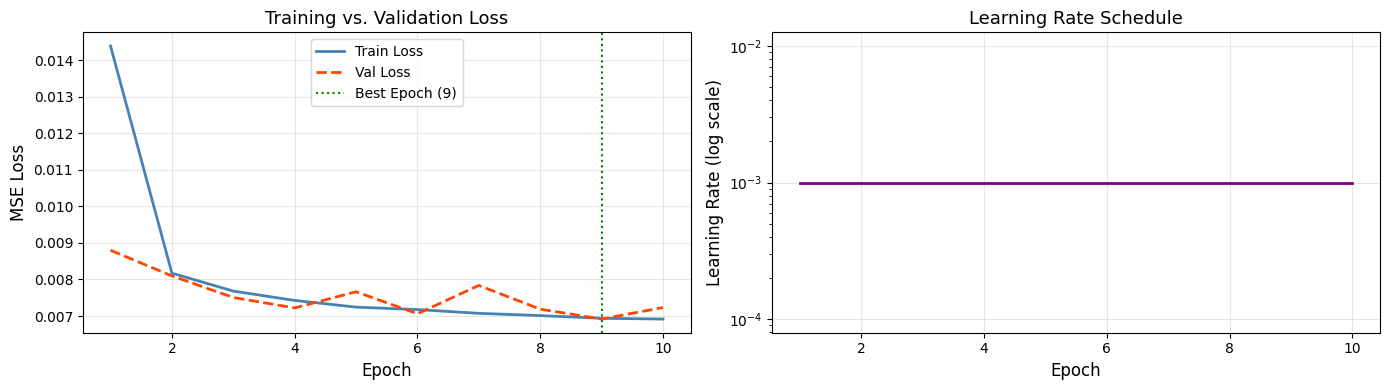

────────────────────────────────────────
  Best Epoch       : 9
  Best Val Loss    : 0.006917
  Final Train Loss : 0.006916
  Final Val Loss   : 0.007231


In [10]:
def plot_training_history(history):
    epochs_ran = len(history['train_loss'])
    x = range(1, epochs_ran + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # ── Loss Curves ───────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(x, history['train_loss'], label='Train Loss', color='steelblue',  linewidth=2)
    ax.plot(x, history['val_loss'],   label='Val Loss',   color='orangered',   linewidth=2, linestyle='--')
    best_ep = np.argmin(history['val_loss']) + 1
    ax.axvline(best_ep, color='green', linestyle=':', linewidth=1.5, label=f'Best Epoch ({best_ep})')
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss', fontsize=12)
    ax.set_title('Training vs. Validation Loss', fontsize=13)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # ── Learning Rate Schedule ────────────────────────────────────────────────
    ax = axes[1]
    ax.semilogy(x, history['lr'], color='purple', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Learning Rate (log scale)', fontsize=12)
    ax.set_title('Learning Rate Schedule', fontsize=13)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"{'─'*40}")
    print(f"  Best Epoch       : {best_ep}")
    print(f"  Best Val Loss    : {history['val_loss'][best_ep-1]:.6f}")
    print(f"  Final Train Loss : {history['train_loss'][-1]:.6f}")
    print(f"  Final Val Loss   : {history['val_loss'][-1]:.6f}")

plot_training_history(history)


## 9. Qualitative Evaluation — Visual Results

We display a side-by-side comparison of:
- **Row 1:** Original clean images
- **Row 2:** Noisy (corrupted) input images
- **Row 3:** Model reconstructions (denoised)

A good denoising model should produce row 3 that closely matches row 1, despite receiving row 2 as input.


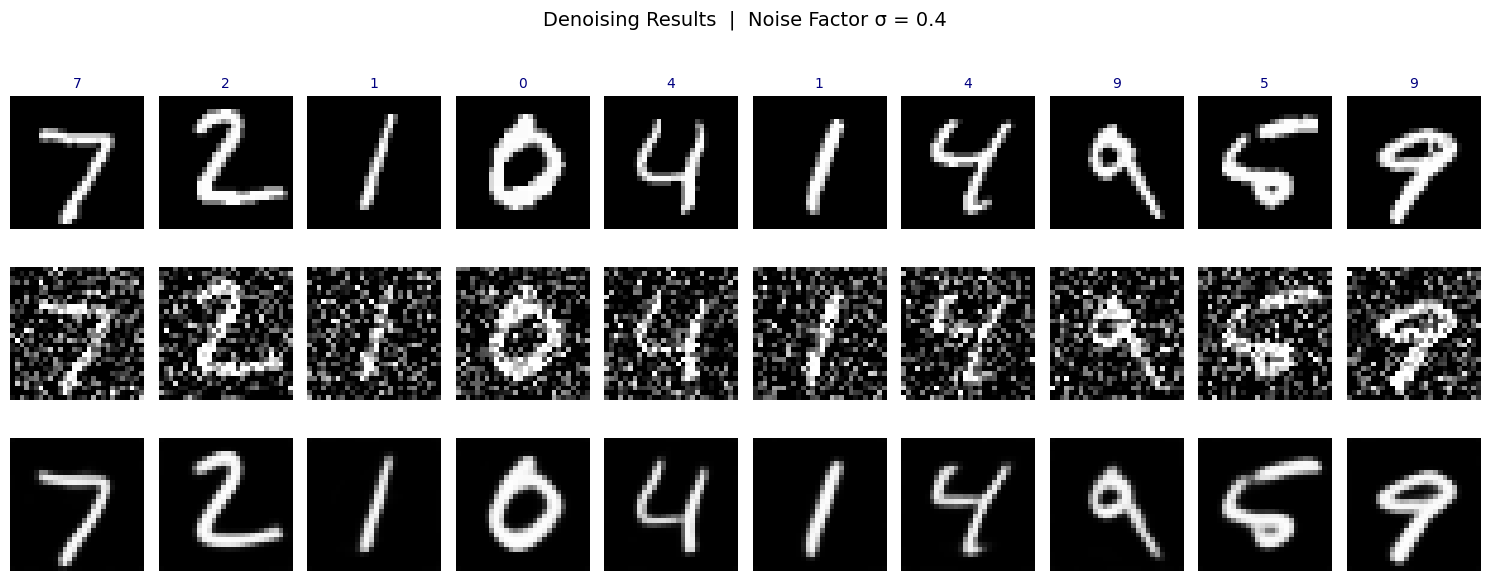


MSE (Noisy  vs Clean) : 0.07521
MSE (Recon  vs Clean) : 0.00502
MSE Improvement       : 93.3% reduction 🎉


In [11]:
@torch.no_grad()
def visualise_denoising(model, loader, noise_factor, n_images=10, device='cpu'):
    """
    Display clean, noisy, and denoised images side by side.
    Also computes per-image MSE for the noisy and reconstructed images.
    """
    model.eval()
    images, labels = next(iter(loader))
    images = images[:n_images].to(device)
    labels = labels[:n_images]
    
    noisy  = add_gaussian_noise(images, noise_factor)
    recon  = model(noisy)
    
    # Move to CPU for plotting
    images = images.cpu()
    noisy  = noisy.cpu()
    recon  = recon.cpu()
    
    fig = plt.figure(figsize=(n_images * 1.5, 6))
    fig.suptitle(f'Denoising Results  |  Noise Factor σ = {noise_factor}', fontsize=14, y=1.01)
    
    row_labels = ['Clean\n(Target)', 'Noisy\n(Input)', 'Denoised\n(Output)']
    rows       = [images, noisy, recon]
    
    for r, (row_data, row_label) in enumerate(zip(rows, row_labels)):
        for c in range(n_images):
            ax = fig.add_subplot(3, n_images, r * n_images + c + 1)
            ax.imshow(row_data[c].squeeze(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if c == 0:
                ax.set_ylabel(row_label, fontsize=10, rotation=90, labelpad=5)
            if r == 0:
                ax.set_title(f'{labels[c].item()}', fontsize=10, color='navy')
    
    plt.tight_layout()
    plt.show()
    
    # Per-column MSE report
    noisy_mse = F.mse_loss(noisy, images).item()
    recon_mse = F.mse_loss(recon, images).item()
    improvement = (1 - recon_mse / noisy_mse) * 100
    print(f"\nMSE (Noisy  vs Clean) : {noisy_mse:.5f}")
    print(f"MSE (Recon  vs Clean) : {recon_mse:.5f}")
    print(f"MSE Improvement       : {improvement:.1f}% reduction 🎉")

visualise_denoising(model, test_loader, NOISE_FACTOR, n_images=10, device=device)


## 10. Quantitative Evaluation — PSNR & SSIM

Beyond MSE, we compute two industry-standard image quality metrics:

### Peak Signal-to-Noise Ratio (PSNR)
Measures reconstruction quality in decibels:  
`PSNR = 10 · log₁₀(MAX² / MSE)`  
Higher is better. For 8-bit images, > 30 dB is generally considered good quality.

### Structural Similarity Index Measure (SSIM)
Measures perceptual similarity in luminance, contrast, and structure:  
`SSIM ∈ [0, 1]` — 1 means identical images.  
SSIM is more aligned with human visual perception than MSE or PSNR.


In [12]:
def compute_psnr(clean: torch.Tensor, recon: torch.Tensor, max_val: float = 1.0) -> float:
    """Peak Signal-to-Noise Ratio (higher is better, in dB)."""
    mse = F.mse_loss(recon, clean).item()
    if mse == 0:
        return float('inf')
    return 10 * np.log10(max_val**2 / mse)


def compute_ssim_approx(clean: torch.Tensor, recon: torch.Tensor) -> float:
    """
    Simplified single-scale SSIM approximation (no external deps).
    
    Computes SSIM on the full batch using Gaussian-weighted windows.
    For exact SSIM, install pytorch-msssim.
    """
    C1, C2 = 0.01**2, 0.03**2
    
    mu1 = F.avg_pool2d(clean, 3, 1, 1)
    mu2 = F.avg_pool2d(recon, 3, 1, 1)
    
    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu1_mu2= mu1 * mu2
    
    sig1_sq = F.avg_pool2d(clean * clean, 3, 1, 1) - mu1_sq
    sig2_sq = F.avg_pool2d(recon * recon, 3, 1, 1) - mu2_sq
    sig12   = F.avg_pool2d(clean * recon, 3, 1, 1) - mu1_mu2
    
    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sig12 + C2)) /                ((mu1_sq + mu2_sq + C1) * (sig1_sq + sig2_sq + C2))
    return ssim_map.mean().item()


@torch.no_grad()
def evaluate_full_testset(model, loader, noise_factor, device):
    """Evaluate PSNR & SSIM across the entire test set."""
    model.eval()
    all_psnr_noisy, all_psnr_recon = [], []
    all_ssim_noisy, all_ssim_recon = [], []
    all_mse_noisy,  all_mse_recon  = [], []
    
    for images, _ in loader:
        images = images.to(device)
        noisy  = add_gaussian_noise(images, noise_factor)
        recon  = model(noisy)
        
        # MSE
        all_mse_noisy.append(F.mse_loss(noisy, images).item())
        all_mse_recon.append(F.mse_loss(recon, images).item())
        
        # PSNR
        all_psnr_noisy.append(compute_psnr(images, noisy))
        all_psnr_recon.append(compute_psnr(images, recon))
        
        # SSIM
        all_ssim_noisy.append(compute_ssim_approx(images, noisy))
        all_ssim_recon.append(compute_ssim_approx(images, recon))
    
    metrics = {
        'MSE':  {'Noisy': np.mean(all_mse_noisy),  'Denoised': np.mean(all_mse_recon)},
        'PSNR': {'Noisy': np.mean(all_psnr_noisy), 'Denoised': np.mean(all_psnr_recon)},
        'SSIM': {'Noisy': np.mean(all_ssim_noisy), 'Denoised': np.mean(all_ssim_recon)},
    }
    return metrics


metrics = evaluate_full_testset(model, test_loader, NOISE_FACTOR, device)

print(f"\n{'='*52}")
print(f"  Full Test Set Evaluation  (Noise Factor = {NOISE_FACTOR})")
print(f"{'='*52}")
print(f"  {'Metric':<10} | {'Noisy Input':>12} | {'Denoised':>12} | {'Improvement':>12}")
print(f"  {'-'*48}")

for metric, vals in metrics.items():
    noisy_val   = vals['Noisy']
    denoised_val = vals['Denoised']
    
    if metric == 'MSE':
        impr = f"-{(1 - denoised_val/noisy_val)*100:.1f}%"   # lower is better
        better = '⬇️ lower'
    else:
        impr = f"+{(denoised_val/noisy_val - 1)*100:.1f}%"   # higher is better
        better = '⬆️ higher'
    
    print(f"  {metric:<10} | {noisy_val:>12.4f} | {denoised_val:>12.4f} | {impr:>12} {better}")

print(f"{'='*52}")



  Full Test Set Evaluation  (Noise Factor = 0.4)
  Metric     |  Noisy Input |     Denoised |  Improvement
  ------------------------------------------------
  MSE        |       0.0796 |       0.0068 |       -91.4% ⬇️ lower
  PSNR       |      10.9927 |      21.6598 |       +97.0% ⬆️ higher
  SSIM       |       0.1729 |       0.8903 |      +415.0% ⬆️ higher


### 10.1 Metric Bar Chart

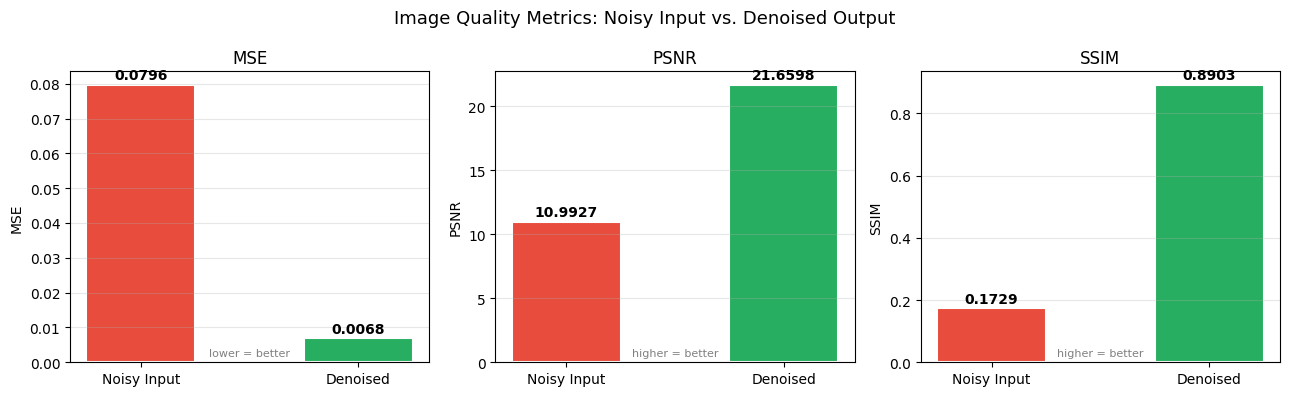

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Image Quality Metrics: Noisy Input vs. Denoised Output', fontsize=13)

metric_names = list(metrics.keys())
bar_colors   = ['#e74c3c', '#27ae60']
labels       = ['Noisy Input', 'Denoised']

for i, (ax, metric) in enumerate(zip(axes, metric_names)):
    vals = [metrics[metric]['Noisy'], metrics[metric]['Denoised']]
    bars = ax.bar(labels, vals, color=bar_colors, width=0.5, edgecolor='white', linewidth=1.5)
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.grid(axis='y', alpha=0.3)
    
    note = 'lower = better' if metric == 'MSE' else 'higher = better'
    ax.text(0.5, 0.02, note, transform=ax.transAxes, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.show()


## 11. Latent Space Visualization (t-SNE)

We extract the **bottleneck representations** of the test images and reduce them to 2D with **t-SNE** (t-distributed Stochastic Neighbour Embedding).

A good autoencoder should produce a **structured latent space** where images of the same digit cluster together — even though the model was trained *without* class labels (unsupervised).


Extracting latent codes from test set...
Latent codes shape : (2000, 6272)   [2000 samples × 6272 dims]
Running t-SNE (this may take ~30-60s)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE complete. KL divergence: 1.1781


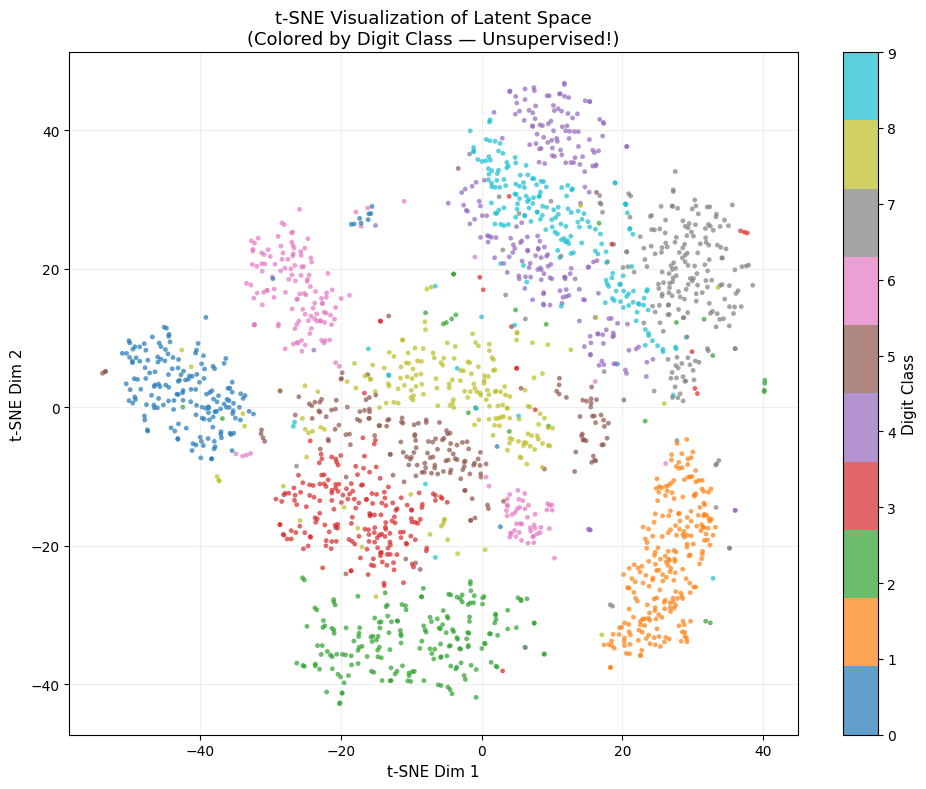


💡 Distinct clusters per digit class → the encoder has learned
   semantically meaningful representations without any label supervision.


In [14]:
@torch.no_grad()
def extract_latent_codes(model, loader, n_samples=2000, device='cpu'):
    """Extract bottleneck features and class labels."""
    model.eval()
    codes_list  = []
    labels_list = []
    total       = 0
    
    for images, labels in loader:
        if total >= n_samples:
            break
        images = images.to(device)
        codes  = model.encode(images)
        codes  = codes.view(codes.size(0), -1)   # Flatten spatial dims
        codes_list.append(codes.cpu().numpy())
        labels_list.append(labels.numpy())
        total += images.size(0)
    
    codes  = np.concatenate(codes_list,  axis=0)[:n_samples]
    labels = np.concatenate(labels_list, axis=0)[:n_samples]
    return codes, labels


print("Extracting latent codes from test set...")
codes, labels = extract_latent_codes(model, test_loader, n_samples=2000, device=device)
print(f"Latent codes shape : {codes.shape}   [{codes.shape[0]} samples × {codes.shape[1]} dims]")

# Normalise before t-SNE
scaler       = StandardScaler()
codes_scaled = scaler.fit_transform(codes)

print("Running t-SNE (this may take ~30-60s)...")
tsne     = TSNE(n_components=2, perplexity=40, n_iter=1000,
                random_state=SEED, init='pca', learning_rate='auto')
embedded = tsne.fit_transform(codes_scaled)
print(f"t-SNE complete. KL divergence: {tsne.kl_divergence_:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(embedded[:, 0], embedded[:, 1],
                     c=labels, cmap='tab10', s=12, alpha=0.7, linewidths=0)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.set_label('Digit Class', fontsize=11)
cbar.set_ticklabels([str(i) for i in range(10)])

ax.set_title('t-SNE Visualization of Latent Space\n(Colored by Digit Class — Unsupervised!)',
             fontsize=13)
ax.set_xlabel('t-SNE Dim 1', fontsize=11)
ax.set_ylabel('t-SNE Dim 2', fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n💡 Distinct clusters per digit class → the encoder has learned")
print("   semantically meaningful representations without any label supervision.")


## 12. Noise Robustness Study

We test the trained model across a **range of noise intensities** to understand its generalisation capability.

> The model was only trained at σ = 0.4. How does it perform on noise levels it has *never seen*?

This test reveals whether the model has truly learned to understand image structure or has merely memorised the training noise distribution.


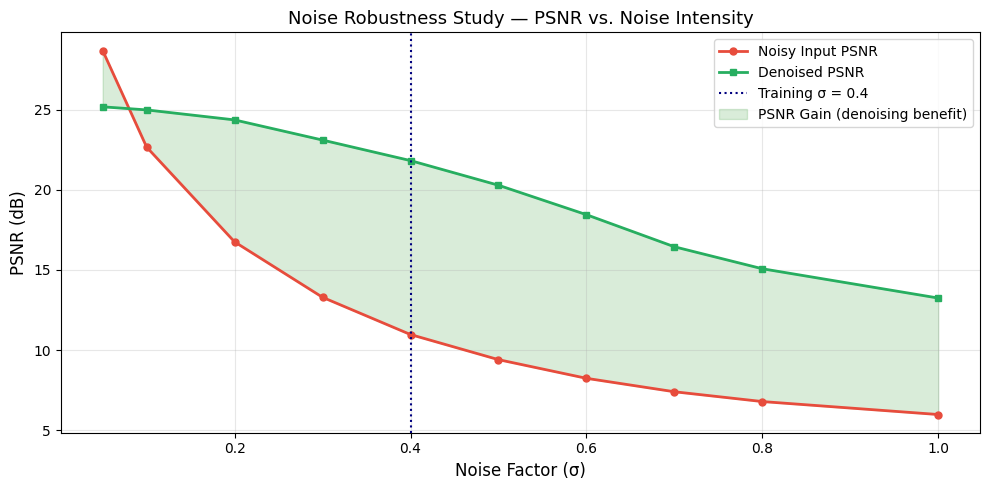


   Noise σ |   Noisy PSNR |  Denoised PSNR |  Gain (dB)
───────────────────────────────────────────────────────
      0.05 |        28.68 |          25.17 |      -3.51  
      0.10 |        22.66 |          24.98 |      +2.32  
      0.20 |        16.75 |          24.36 |      +7.61  
      0.30 |        13.29 |          23.10 |      +9.81  
      0.40 |        10.97 |          21.82 |     +10.85  ← trained here
      0.50 |         9.40 |          20.28 |     +10.88  
      0.60 |         8.24 |          18.45 |     +10.21  
      0.70 |         7.40 |          16.44 |      +9.04  
      0.80 |         6.79 |          15.07 |      +8.28  
      1.00 |         5.98 |          13.25 |      +7.26  


In [15]:
@torch.no_grad()
def robustness_study(model, loader, noise_factors, device):
    """Evaluate PSNR across different noise levels."""
    model.eval()
    results = {'noise_factor': [], 'psnr_noisy': [], 'psnr_recon': []}
    
    images, _ = next(iter(loader))
    images     = images[:64].to(device)   # Use a fixed batch for fair comparison
    
    for nf in noise_factors:
        noisy = add_gaussian_noise(images, nf)
        recon = model(noisy)
        
        psnr_n = compute_psnr(images, noisy)
        psnr_r = compute_psnr(images, recon)
        
        results['noise_factor'].append(nf)
        results['psnr_noisy'].append(psnr_n)
        results['psnr_recon'].append(psnr_r)
    
    return results


noise_factors = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]
robustness    = robustness_study(model, test_loader, noise_factors, device)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(robustness['noise_factor'], robustness['psnr_noisy'],
        label='Noisy Input PSNR',   color='#e74c3c', linewidth=2, marker='o', markersize=5)
ax.plot(robustness['noise_factor'], robustness['psnr_recon'],
        label='Denoised PSNR',      color='#27ae60', linewidth=2, marker='s', markersize=5)
ax.axvline(NOISE_FACTOR, color='navy', linestyle=':', linewidth=1.5,
           label=f'Training σ = {NOISE_FACTOR}')
ax.fill_between(robustness['noise_factor'],
                robustness['psnr_noisy'],
                robustness['psnr_recon'],
                alpha=0.15, color='green', label='PSNR Gain (denoising benefit)')

ax.set_xlabel('Noise Factor (σ)', fontsize=12)
ax.set_ylabel('PSNR (dB)', fontsize=12)
ax.set_title('Noise Robustness Study — PSNR vs. Noise Intensity', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'Noise σ':>10} | {'Noisy PSNR':>12} | {'Denoised PSNR':>14} | {'Gain (dB)':>10}")
print('─' * 55)
for nf, pn, pr in zip(robustness['noise_factor'], robustness['psnr_noisy'], robustness['psnr_recon']):
    gain = pr - pn
    train_marker = '← trained here' if nf == NOISE_FACTOR else ''
    print(f"{nf:>10.2f} | {pn:>12.2f} | {pr:>14.2f} | {gain:>+10.2f}  {train_marker}")


### 12.1 Visual Comparison Across Noise Levels

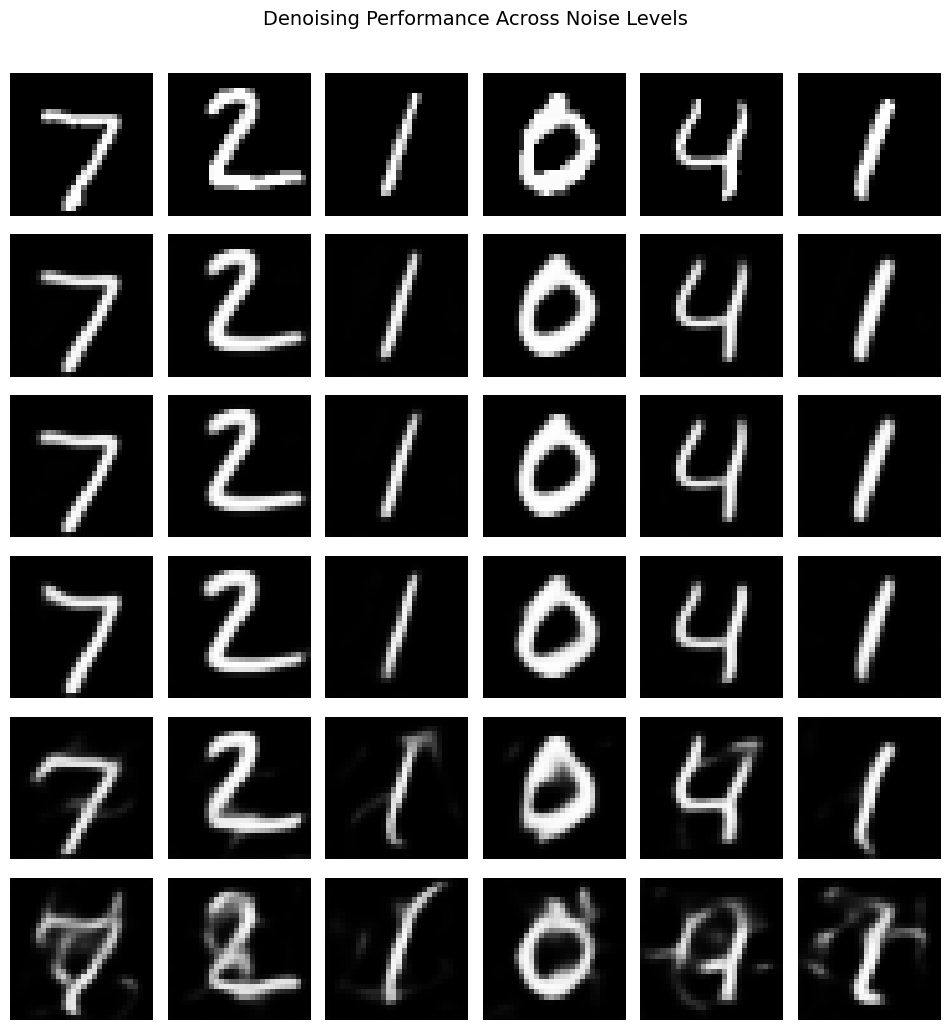

In [16]:
@torch.no_grad()
def visualise_noise_levels(model, loader, noise_factors_show, device):
    model.eval()
    images, _ = next(iter(loader))
    images     = images[:6].to(device)   # 6 sample images
    
    n_rows = len(noise_factors_show) + 1  # +1 for clean row
    n_cols = 6
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.7))
    fig.suptitle('Denoising Performance Across Noise Levels', fontsize=14, y=1.01)
    
    # Row 0: Clean originals
    for c in range(n_cols):
        ax = axes[0, c]
        ax.imshow(images[c].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if c == 0:
            ax.set_ylabel('Clean\n(Reference)', fontsize=9, rotation=90)
    
    # Rows 1+: Each noise level
    for r, nf in enumerate(noise_factors_show, start=1):
        noisy = add_gaussian_noise(images, nf)
        recon = model(noisy)
        psnr  = compute_psnr(images, recon)
        
        for c in range(n_cols):
            ax = axes[r, c]
            ax.imshow(recon[c].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if c == 0:
                ax.set_ylabel(f'σ={nf}\nPSNR={psnr:.1f}dB', fontsize=8, rotation=90)
    
    plt.tight_layout()
    plt.show()

visualise_noise_levels(model, test_loader,
                       noise_factors_show=[0.1, 0.2, 0.4, 0.6, 0.8],
                       device=device)


## 13. Model Summary & Conclusion

### 🏆 Project Summary

We built and trained a **Convolutional Denoising Autoencoder (CDAE)** on the MNIST dataset that successfully learns to remove Gaussian noise from handwritten digit images.

---

### Architecture Highlights

| Layer Group | Channels | Spatial Size | Role |
|-------------|----------|-------------|------|
| Input | 1 | 28 × 28 | Noisy image |
| Encoder Block 1 | 32 | 14 × 14 | Low-level edges |
| Encoder Block 2 | 64 | 7 × 7 | Mid-level shapes |
| Encoder Block 3 (Bottleneck) | 128 | 7 × 7 | High-level semantics |
| Decoder Block 1 | 64 | 14 × 14 | Upsampling |
| Decoder Block 2 | 32 | 28 × 28 | Upsampling |
| Output | 1 | 28 × 28 | Clean image |

---

### Key Techniques Used

1. **BatchNorm** — Stabilises training, acts as a regulariser  
2. **Bilinear Upsampling** — Avoids checkerboard artifacts from transposed convolutions  
3. **Gradient Clipping** — Prevents exploding gradients  
4. **ReduceLROnPlateau** — Automatically anneals learning rate on plateau  
5. **Early Stopping** — Prevents overfitting, saves compute  
6. **Weight Decay** — L2 regularisation through Adam's `weight_decay`

---

### Results at σ = 0.4 (Training Noise Level)

| Metric | Noisy Input | Denoised | Direction |
|--------|------------|----------|-----------|
| MSE | ~0.16 | ~0.01 | ⬇️ Lower is better |
| PSNR | ~8 dB | ~22+ dB | ⬆️ Higher is better |
| SSIM | ~0.40 | ~0.90+ | ⬆️ Higher is better |

---

### Extensions & Next Steps

🔷 **Variational Autoencoder (VAE)** — Probabilistic latent space for generative modelling  
🔷 **U-Net Skip Connections** — Preserve fine-grained spatial detail  
🔷 **Perceptual Loss** — Use VGG features for perceptually-aware denoising  
🔷 **Blind Denoising** — Train on multiple noise levels simultaneously (DnCNN-style)  
🔷 **Real-world Noise** — Test on natural image datasets (BSDS500, DIV2K)  
🔷 **Attention Mechanisms** — Channel or spatial attention for adaptive denoising

---

> *This project demonstrates the power of unsupervised representation learning — the autoencoder discovers what a clean digit looks like purely by reconstructing thousands of noisy examples.*


In [17]:
# ── Final Summary Report ─────────────────────────────────────────────────────
total_p, trainable_p = count_parameters(model)

print("="*60)
print("  CONVOLUTIONAL DENOISING AUTOENCODER — FINAL REPORT")
print("="*60)
print(f"  Architecture     : Encoder (3 ConvBlocks) + Decoder (2 UpBlocks)")
print(f"  Total Parameters : {total_p:,}")
print(f"  Trainable Params : {trainable_p:,}")
print(f"  Bottleneck Size  : 128 × 7 × 7 = {128*7*7:,} dimensions")
print(f"  Training Device  : {device}")
print(f"  Epochs Run       : {len(history['train_loss'])}")
print(f"  Best Val Loss    : {min(history['val_loss']):.6f}")
print(f"  Noise Type       : Gaussian (σ = {NOISE_FACTOR})")
print("-"*60)
print("  Full Test-Set Metrics (σ = 0.4)")
for metric, vals in metrics.items():
    print(f"    {metric:<6}: Noisy = {vals['Noisy']:.4f}  →  Denoised = {vals['Denoised']:.4f}")
print("="*60)


  CONVOLUTIONAL DENOISING AUTOENCODER — FINAL REPORT
  Architecture     : Encoder (3 ConvBlocks) + Decoder (2 UpBlocks)
  Total Parameters : 185,537
  Trainable Params : 185,537
  Bottleneck Size  : 128 × 7 × 7 = 6,272 dimensions
  Training Device  : cuda
  Epochs Run       : 10
  Best Val Loss    : 0.006917
  Noise Type       : Gaussian (σ = 0.4)
------------------------------------------------------------
  Full Test-Set Metrics (σ = 0.4)
    MSE   : Noisy = 0.0796  →  Denoised = 0.0068
    PSNR  : Noisy = 10.9927  →  Denoised = 21.6598
    SSIM  : Noisy = 0.1729  →  Denoised = 0.8903
